In [1]:
#imort libararies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [2]:
#LOAD AND INSPECT THE DATA
df=pd.read_csv("smartCart.csv")
df.head()
# df.info()
# df.describe()
# df.isnull().sum()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
# DATA CLEANING(Handling missing values)
df["Income"] = df["Income"].fillna(df["Income"].median())

#FEATURE ENGINEERING(Age from Year_Birth)
df["Age"]=2026-df["Year_Birth"]

# df.drop(columns=["Year_Birth"], inplace=True)
# df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age'],
      dtype='object')

In [4]:
#Customer tenure (days since joining)
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["customer_tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days
df.head()

# Total spending across all products
df["total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

#Total children in household
df["total_children"]=df["Kidhome"]+df["Teenhome"]


In [5]:
#education 
df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate","2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "Master":"PostGraduate","PhD":"PostGraduate"
})
df["Education"].value_counts()

#marital status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [6]:
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone","Widow":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})

In [7]:
#remove unnecessary features
cols=["ID","Year_Birth","Marital_Status","Teenhome","Kidhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [8]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [9]:
#handle outliers
cols=["Income","Recency","Age","total_children","Response","total_spending"]
#relative plot
# sns.pairplot(df_cleaned[cols])

In [10]:
#removing outliers
print("data size with outliers:",len(df_cleaned))

df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


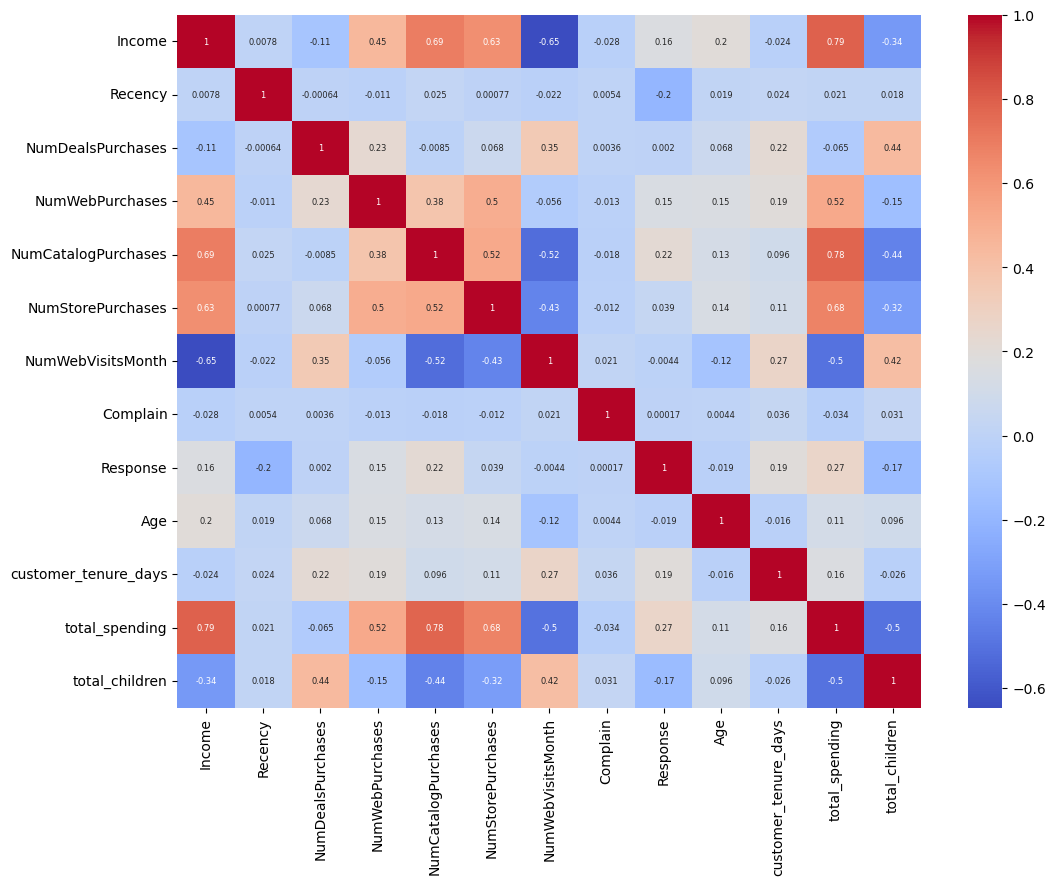

In [11]:
#corelation
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(12,9))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)
plt.show()

In [12]:
#Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [13]:
#concatinatting
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [14]:
df_encoded.head()
df_encoded.shape

(2236, 18)

In [15]:
#Feature Scaling(Standardizing features before PCA and clustering)
X=df_encoded
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [16]:
#visulaization  2D
#PCA TO REDUCE SHAPE ..WE HAVE MULTIPLE NUMBERS OF FEATURES
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.23163158 0.11385454 0.10405815]
Total variance captured: 0.4495442703569007


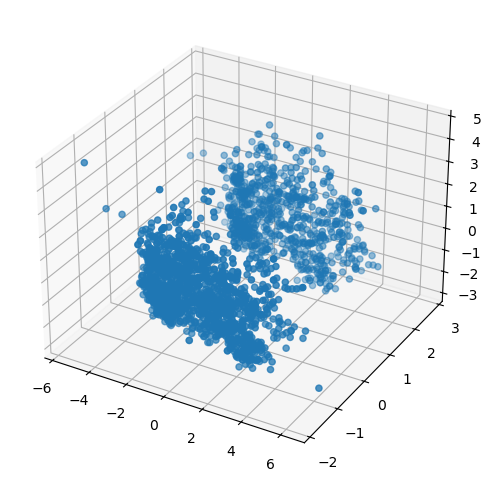

In [17]:
#PCA Visualization 
fig=plt.figure(figsize=(9,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2])

In [18]:
#analyze the k value for making clusters (Optimal Number of Clusters)
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_transform(X_pca)
    wcss.append(kmeans.inertia_)

knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print("best k=",optimal_k)

best k= 4


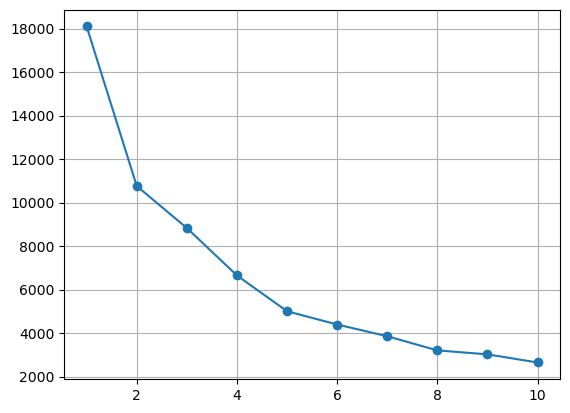

In [19]:
#plotting our k value 
plt.plot(range(1,11),wcss,marker="o")
plt.grid()

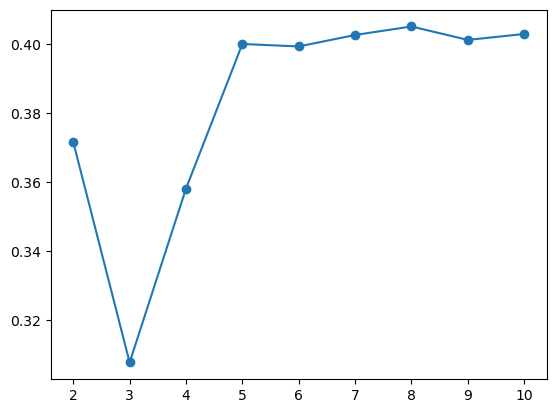

In [20]:
#k value using silhouette score
from sklearn.metrics import silhouette_score

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker="o")

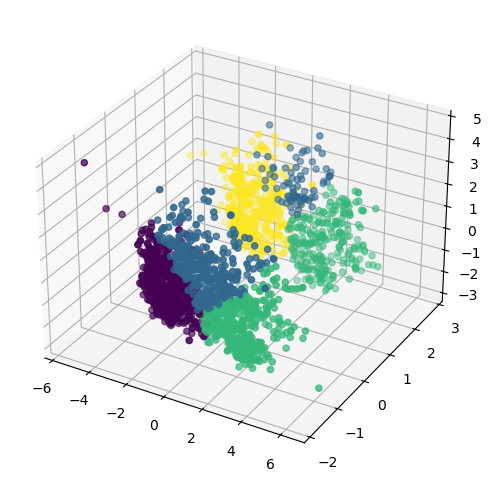

In [21]:
#Apply Clustering Algorithms 
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)
#plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)



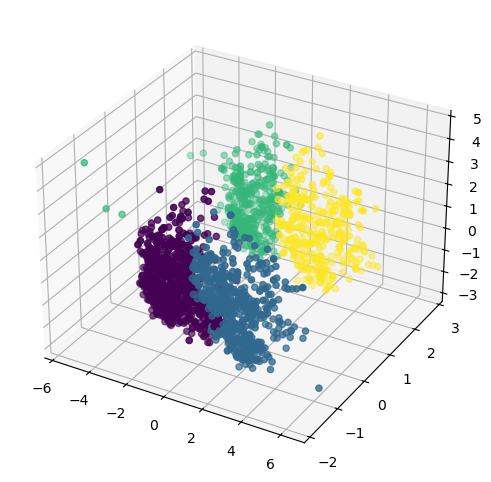

In [22]:
#using agglomaerative clustring
from sklearn.cluster import AgglomerativeClustering

agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg.fit_predict(X_pca)


#plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

<Axes: xlabel='cluster', ylabel='count'>

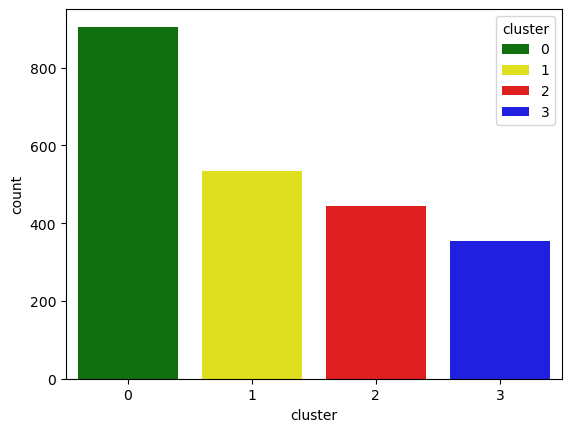

In [23]:
# CHARCATERIZATION OF CLUSTERS
df_cleaned["cluster"]=labels_agg
df_cleaned.head()

#create countplot 
pal=["green","yellow","red","blue"]
sns.countplot(x=df_cleaned["cluster"],palette=pal,hue=df_cleaned["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

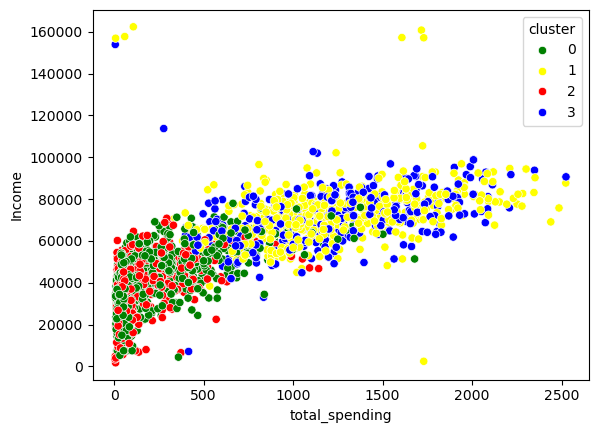

In [24]:
#INCOME AND SPENDING PATTERNS
sns.scatterplot(x=df_cleaned["total_spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pal)